# Table: Bound slope analyses — all blocks, OL and MX

Extends the Panel C and Panel D analyses from Figure 3 to all 6 blocks for both
the OL (online / blocked SNR) and MX (mixed SNR) datasets.

Two analyses, each computed per participant × block:

### 1. Bound ~ DT &nbsp;&nbsp;(Figure 3 Panel C)
Linear regression of |bound| on DT (DT ≥ 2).  
Tests whether inferred bounds grow systematically with decision time.  
**Null**: median slope = 0.

### 2. Δbound ~ bound &nbsp;&nbsp;(Figure 3 Panel D)
Linear regression of Δ|bound|ₜ = |bound|ₜ − |bound|ₜ₋₁ on current |bound|ₜ.  
Tests whether large bounds tend to revert toward the mean across consecutive trials.  
Slope = −1 → pure regression to mean; slope = 0 → no systematic trial-to-trial change.  
**Null**: median slope = −1.

---

**Table summary per block**: median [IQR] of per-participant values,
plus Wilcoxon signed-rank p-value (vs. stated null) for each analysis.

**Data**: Both datasets loaded with `combine_snr=False` to retain all 6 raw
block / SNR combinations. Good-trial filter: DT ≥ 2, trial ≥ 10, no wall hit,
no RT below the RT cutoff. Additional DT ≥ 2 filter for analysis 1.

In [6]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import scipy.stats
import matplotlib.pyplot as plt

from pigeon.data import get_data_table, get_good_trial_array
from pigeon.pathDefaults import FIGURES_DIR

In [7]:
# combine_snr=False retains each block as a separate condition rather than
# pooling across SNR levels, giving one row per block in the table.
data_table_ol = get_data_table(task_type='OL', combine_snr=False)
data_table_mx = get_data_table(task_type='MX', combine_snr=False)

BLOCKS = sorted(data_table_ol['block_index'].dropna().unique().astype(int))
print('OL blocks:', BLOCKS)
print('MX blocks:', sorted(data_table_mx['block_index'].dropna().unique().astype(int)))

  1: /Users/jigold/GoldWorks/Mirror_jigold/Manuscripts/2023_Pigeon/Data/Pigeon_OL/prolificcsvs/PigeonTask_2022-11-21_14h39.24.096.csv
  2: /Users/jigold/GoldWorks/Mirror_jigold/Manuscripts/2023_Pigeon/Data/Pigeon_OL/prolificcsvs/PigeonTask_2022-11-21_15h37.48.260.csv
  3: /Users/jigold/GoldWorks/Mirror_jigold/Manuscripts/2023_Pigeon/Data/Pigeon_OL/prolificcsvs/PigeonTask_2022-11-21_16h34.46.761.csv
  4: /Users/jigold/GoldWorks/Mirror_jigold/Manuscripts/2023_Pigeon/Data/Pigeon_OL/prolificcsvs/PigeonTask_2022-11-21_16h35.25.285.csv
  5: /Users/jigold/GoldWorks/Mirror_jigold/Manuscripts/2023_Pigeon/Data/Pigeon_OL/prolificcsvs/PigeonTask_2022-11-21_16h36.33.669.csv
  6: /Users/jigold/GoldWorks/Mirror_jigold/Manuscripts/2023_Pigeon/Data/Pigeon_OL/prolificcsvs/PigeonTask_2022-11-21_16h36.41.364.csv
  7: /Users/jigold/GoldWorks/Mirror_jigold/Manuscripts/2023_Pigeon/Data/Pigeon_OL/prolificcsvs/PigeonTask_2022-11-21_16h36.49.086.csv
  8: /Users/jigold/GoldWorks/Mirror_jigold/Manuscripts/2023_Pi

In [8]:
def compute_slope_stats(data_table, blocks):
    """
    For each block compute per-subject statistics:
      slopes_c : |bound| ~ DT slopes  (Figure 3 Panel C, DT >= 2)
      slopes_d : Δ|bound| ~ |bound| slopes  (Figure 3 Panel D)

    Both analyses draw from the same base trial set (good-quality trials with a
    valid bound).  A subject is included if they have >= 3 valid data points.

    Returns a list of row-dicts (one per block) with median, IQR, Wilcoxon p,
    and participant count n.
    """
    subjects = np.sort(data_table['subject_index'].dropna().unique())
    good     = get_good_trial_array(data_table)
    rows = []

    for block in blocks:
        lg_base = (
            good &
            data_table['bound'].notna() &
            (data_table['block_index'] == block)
        )

        n_subj = sum(
            1 for subj in subjects
            if (lg_base & (data_table['subject_index'] == subj)).sum() >= 3
        )

        slopes_c = []
        slopes_d = []

        for subj in subjects:
            ls = lg_base & (data_table['subject_index'] == subj)

            # ── Analysis 1: |bound| ~ DT (DT >= 2) ──────────────────────────────
            sub_c = data_table[ls & (data_table['DT'] >= 2)]
            if len(sub_c) >= 3:
                dts = sub_c['DT'].to_numpy(dtype=float)
                ab  = np.abs(sub_c['bound'].to_numpy(dtype=float))
                fin = np.isfinite(dts) & np.isfinite(ab)
                if fin.sum() >= 3:
                    try:
                        s, *_ = scipy.stats.linregress(dts[fin], ab[fin])
                        slopes_c.append(s)
                    except ValueError:
                        pass

            # ── Analysis 2: Δ|bound| ~ |bound| ──────────────────────────────────
            sub_d = data_table[ls].sort_values('trial_number')
            if len(sub_d) >= 3:
                ab    = np.abs(sub_d['bound'].to_numpy(dtype=float))
                curr  = ab[1:]
                delta = curr - ab[:-1]
                fin   = np.isfinite(curr) & np.isfinite(delta)
                if fin.sum() >= 3:
                    try:
                        s, *_ = scipy.stats.linregress(curr[fin], delta[fin])
                        slopes_d.append(s)
                    except ValueError:
                        pass

        def summarize(slopes, null=0.0):
            arr = np.asarray(slopes, dtype=float)
            if int(np.isfinite(arr).sum()) < 3:
                return dict(median=np.nan, q25=np.nan, q75=np.nan, p=np.nan)
            q25, med, q75 = np.percentile(arr, [25, 50, 75])
            try:
                _, p = scipy.stats.wilcoxon(arr - null)
            except ValueError:
                p = np.nan
            return dict(median=med, q25=q25, q75=q75, p=p)

        sc = summarize(slopes_c, null=0.0)
        sd = summarize(slopes_d, null=-1.0)
        rows.append(dict(
            block=block,
            n=n_subj,
            c_median=sc['median'], c_q25=sc['q25'], c_q75=sc['q75'], c_p=sc['p'],
            d_median=sd['median'], d_q25=sd['q25'], d_q75=sd['q75'], d_p=sd['p'],
        ))

    return rows

In [9]:
rows_ol = compute_slope_stats(data_table_ol, BLOCKS)
rows_mx = compute_slope_stats(data_table_mx, BLOCKS)

Dataset,Block (n),|bound|~DT median [IQR],p (H₀: 0),Δbound~bound median [IQR],p (H₀: 1)
OL,1 (57),"0.0017 [-0.0097, 0.0086]",0.9398,"0.9706 [0.8773, 1.0829]",<0.0001
OL,2 (59),"-0.0024 [-0.0065, 0.0032]",0.0799,"0.9734 [0.8308, 1.0939]",<0.0001
OL,3 (53),"-0.0017 [-0.0102, 0.0047]",0.1381,"0.9772 [0.8697, 1.0644]",<0.0001
OL,4 (53),"0.0074 [-0.0140, 0.0387]",0.0949,"1.0108 [0.8989, 1.1489]",<0.0001
OL,5 (57),"-0.0013 [-0.0126, 0.0168]",0.9740,"1.0035 [0.8877, 1.0951]",<0.0001
OL,6 (49),"0.0001 [-0.0281, 0.0207]",0.8054,"1.0935 [0.8589, 1.2231]",<0.0001
MX,1 (60),"0.0034 [-0.0025, 0.0133]",0.0216,"0.9797 [0.9103, 1.0600]",<0.0001
MX,2 (59),"0.0040 [-0.0033, 0.0097]",0.0309,"0.9913 [0.8832, 1.0738]",<0.0001
MX,3 (54),"-0.0031 [-0.0111, 0.0090]",0.4358,"1.0218 [0.8949, 1.1298]",<0.0001
MX,4 (54),"0.0094 [-0.0046, 0.0221]",0.0149,"1.0591 [0.9213, 1.1387]",<0.0001


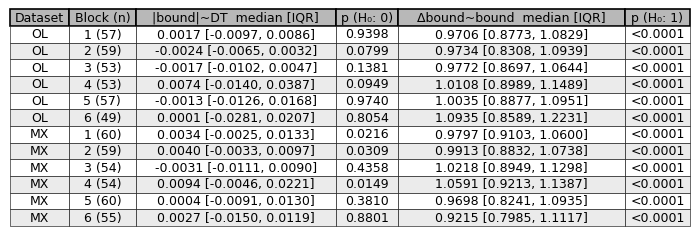

Saved /Users/jigold/Library/CloudStorage/Box-Box/GoldLab/Projects/2025_Pigeon/Figures/Table_slopeAnalyses.pdf


In [10]:
def build_table(rows, dataset):
    def fmt_slope(med, q25, q75):
        if np.isnan(med):
            return 'NA'
        return f'{med:.4f} [{q25:.4f}, {q75:.4f}]'

    def fmt_p(p):
        if np.isnan(p):
            return 'NA'
        return f'{p:.4f}' if p >= 0.0001 else '<0.0001'

    records = []
    for r in rows:
        records.append({
            'Dataset':                    dataset,
            'Block (n)':                  f"{r['block']} ({r['n']})",
            '|bound|~DT  median [IQR]':   fmt_slope(r['c_median'], r['c_q25'], r['c_q75']),
            'p (H\u2080: 0)':                  fmt_p(r['c_p']),
            'Δbound~bound  median [IQR]': fmt_slope(r['d_median'], r['d_q25'], r['d_q75']),
            'p (H\u2080: 1)':                  fmt_p(r['d_p']),
        })
    return pd.DataFrame(records)


df_ol  = build_table(rows_ol, 'OL')
df_mx  = build_table(rows_mx, 'MX')
df_all = pd.concat([df_ol, df_mx], ignore_index=True)

pd.set_option('display.max_colwidth', None)
pd.set_option('display.width', 200)
display(df_all.style.hide())

# ── Save as PDF ────────────────────────────────────────────────────────────────
CM  = 1 / 2.54
FS  = 9
WID = 22   # cm

HEADER_BG = (0.72, 0.72, 0.72)   # darker gray for header row
ROW_GRAY  = (0.92, 0.92, 0.92)   # alternating light-gray data rows
ROW_WHITE = (1.00, 1.00, 1.00)   # alternating white data rows
THICK_LW  = 1.2                  # header border
THIN_LW   = 0.4                  # inner grid lines

fig, ax = plt.subplots(figsize=(WID * CM, 1))   # height adjusted by bbox_inches='tight'
ax.axis('off')

tbl = ax.table(
    cellText=df_all.values.tolist(),
    colLabels=list(df_all.columns),
    cellLoc='center',
    loc='center',
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(FS)
tbl.auto_set_column_width(col=list(range(len(df_all.columns))))

for (row, col), cell in tbl.get_celld().items():
    if row == 0:
        cell.set_facecolor(HEADER_BG)
        cell.set_linewidth(THICK_LW)
    else:
        cell.set_facecolor(ROW_GRAY if row % 2 == 0 else ROW_WHITE)
        cell.set_linewidth(THIN_LW)

out = FIGURES_DIR / 'Table_slopeAnalyses.pdf'
fig.savefig(out, dpi=300, bbox_inches='tight')
plt.show()
print(f'Saved {out}')